In [4]:
# 符号回归的结果
# 加载测试集
import numpy as np
import pandas as pd
df_qf = pd.read_excel('test_set_final.xlsx', index_col=0)
df_kl = pd.read_excel('test_set_final.xlsx', index_col=0)

# 提取特征
X_test_qf = df_qf.drop(columns=['Precipitate Distribution', '屈服强度', '抗拉强度 (UTS)', '追踪编号'])
X_test_kl = df_kl.drop(columns=['Precipitate Distribution', '屈服强度', '抗拉强度 (UTS)', '追踪编号'])

Y_test_qf = df_qf['屈服强度']
Y_test_kl = df_kl['抗拉强度 (UTS)']

import numpy as np

# qf 预测函数
def predict_qf(X):
    t1 = ((X['MagpieData avg_dev MeltingT'] * 0.12248593) - X['Grain Size']) * 0.044649825 + 4.9685597
    part1 = np.exp(t1) - X['Yang omega']
    
    t2 = X['Yang omega'] * (X['Interant electrons'] + 13.838549)
    part2 = X['Interant electrons'] + (
        X['frac f valence electrons'] * (0.39203042 * np.square(t2))
    ) + 108.030975

    part3 = np.square(np.cos(X['MagpieData avg_dev MeltingT'])) * 16.545942
    
    return part1 + part2 - part3

# kl 预测函数
def predict_kl(X):
    t1 = 313.5205 / (X['Grain Size'] + 14.417686) + 2.7504566
    part1 = t1 + X['MagpieData mean GSvolume_pa'] + X['Interant electrons']
    
    t2 = np.square(np.cos(0.62931544 - X['Mixing enthalpy']))
    t3 = np.square(np.cos(X['MagpieData range GSvolume_pa'])) + 2.763029
    part2 = t2 * t3 + 3.2129428

    part3 = np.square(np.cos(3.711393 * X['Interant electrons']))
    part4 = np.exp(np.square(np.cos(X['Interant d electrons'])))

    return (part1 * part2) - part3 + part4

# 计算预测值
y_pred_qf = predict_qf(X_test_qf)
y_pred_kl = predict_kl(X_test_kl)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# qf 精度评估
mae_qf = mean_absolute_error(Y_test_qf, y_pred_qf)
rmse_qf = np.sqrt(mean_squared_error(Y_test_qf, y_pred_qf))
r2_qf = r2_score(Y_test_qf, y_pred_qf)

# kl 精度评估
mae_kl = mean_absolute_error(Y_test_kl, y_pred_kl)
rmse_kl = np.sqrt(mean_squared_error(Y_test_kl, y_pred_kl))
r2_kl = r2_score(Y_test_kl, y_pred_kl)

print("qf 精度:")
print(f"MAE: {mae_qf:.3f}, RMSE: {rmse_qf:.3f}, R²: {r2_qf:.3f}")

print("kl 精度:")
print(f"MAE: {mae_kl:.3f}, RMSE: {rmse_kl:.3f}, R²: {r2_kl:.3f}")





qf 精度:
MAE: 44.845, RMSE: 59.600, R²: 0.630
kl 精度:
MAE: 43.900, RMSE: 55.887, R²: 0.544


In [ ]:
import numpy as np
import pandas as pd
import joblib

# 定义文件夹路径
folder_path_qf = "qf_models"
folder_path_kl = "kl_models"

# 定义权重
weights_qf = {'xgboost': 0.7 / 5, 'rf': 0.3 / 5}
weights_kl = {'xgboost': 0.5 / 5, 'rf': 0.5 / 5}

# 加载测试集
df_qf = pd.read_excel('qf_models/test_set_new.xlsx', index_col=0)
df_kl = pd.read_excel('kl_models/test_set_new.xlsx', index_col=0)

# 提取特征
X_test_qf = df_qf.drop(columns=['Precipitate Distribution', '屈服强度', '抗拉强度 (UTS)', '追踪编号'])
X_test_kl = df_kl.drop(columns=['Precipitate Distribution', '屈服强度', '抗拉强度 (UTS)', '追踪编号'])

# 初始化预测结果数组
predicted_YS = np.zeros(X_test_qf.shape[0])
predicted_TS = np.zeros(X_test_kl.shape[0])

# 计算 Yield Strength 预测值
for model_name, weight in weights_qf.items():
    for i in range(1, 6):
        model_path = f'{folder_path_qf}/{model_name}{i}_new.pkl'
        model = joblib.load(model_path)
        predicted_YS += model.predict(X_test_qf) * weight

# 计算 Tensile Strength 预测值
for model_name, weight in weights_kl.items():
    for i in range(1, 6):
        model_path = f'{folder_path_kl}/{model_name}{i}_new.pkl'
        model = joblib.load(model_path)
        predicted_TS += model.predict(X_test_kl) * weight

# 添加预测值到测试集
df_qf["Predicted YS"] = predicted_YS
df_kl["Predicted TS"] = predicted_TS

# 保存结果
output_qf = "qf_predicted_results.xlsx"
output_kl = "kl_predicted_results.xlsx"
df_qf.to_excel(output_qf, index=True)
df_kl.to_excel(output_kl, index=True)

print("Predictions completed and saved.")


D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.2 when using version 1.5.1. This m

Predictions completed and saved.


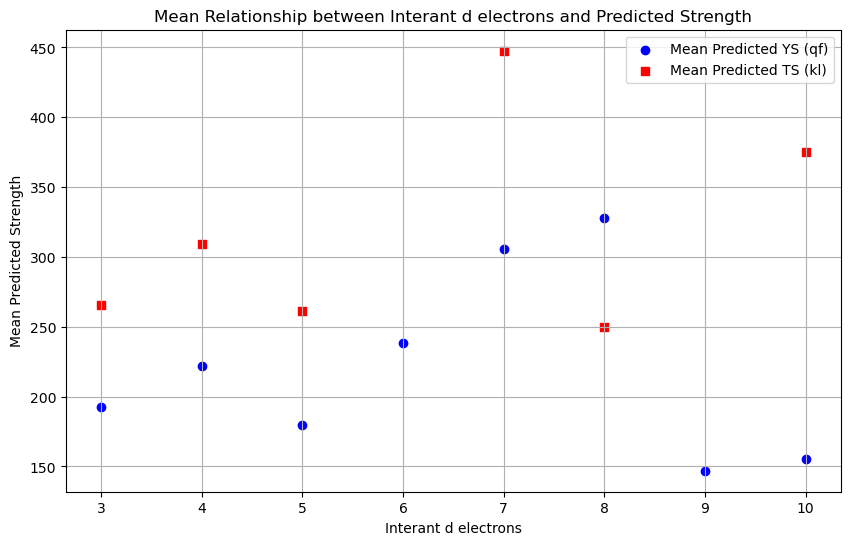

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取预测结果
qf_results = pd.read_excel("qf_predicted_results.xlsx", index_col=0)
kl_results = pd.read_excel("kl_predicted_results.xlsx", index_col=0)

# 过滤 "Interant d electrons" 在 3 到 10 之间的数据
qf_filtered = qf_results[(qf_results["Interant d electrons"] >= 3) & (qf_results["Interant d electrons"] <= 10)]
kl_filtered = kl_results[(kl_results["Interant d electrons"] >= 3) & (kl_results["Interant d electrons"] <= 10)]

# 按 "Interant d electrons" 分组并计算均值
qf_grouped = qf_filtered.groupby("Interant d electrons")["Predicted YS"].mean()
kl_grouped = kl_filtered.groupby("Interant d electrons")["Predicted TS"].mean()

# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(qf_grouped.index, qf_grouped.values, label="Mean Predicted YS (qf)", color='blue', marker='o')
plt.scatter(kl_grouped.index, kl_grouped.values, label="Mean Predicted TS (kl)", color='red', marker='s')

plt.xlabel("Interant d electrons")
plt.ylabel("Mean Predicted Strength")
plt.title("Mean Relationship between Interant d electrons and Predicted Strength")
plt.legend()
plt.grid(True)
plt.show()


D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23624 (\N{CJK UNIFIED IDEOGRAPH-5C48}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26381 (\N{CJK UNIFIED IDEOGRAPH-670D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


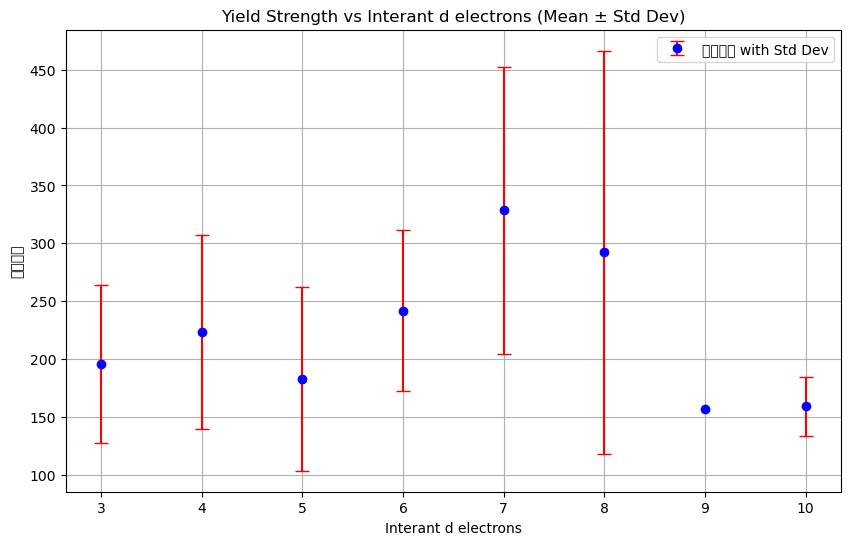

D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25239 (\N{CJK UNIFIED IDEOGRAPH-6297}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25289 (\N{CJK UNIFIED IDEOGRAPH-62C9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


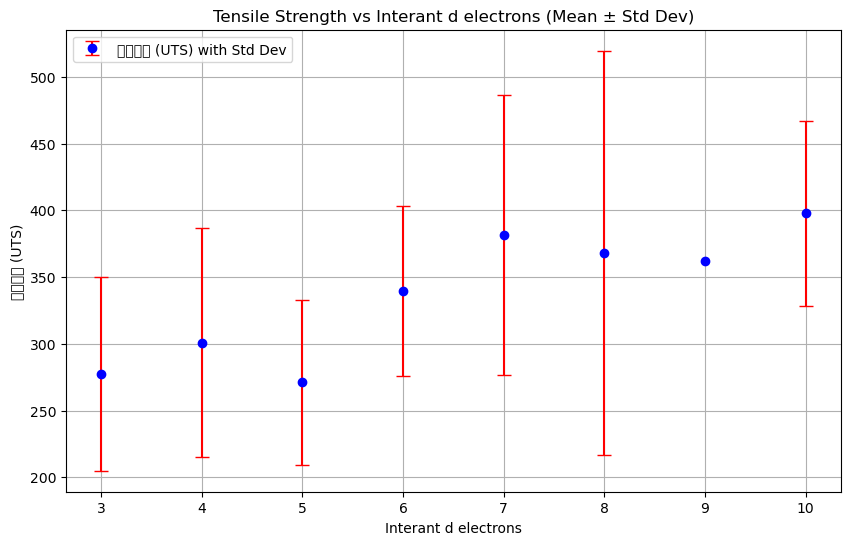

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取 Excel 文件
df = pd.read_excel("FULL_general.xlsx", index_col=0)

# 过滤 "Interant d electrons" 在 3 到 10 之间的数据
filtered_df = df[(df["Interant d electrons"] >= 3) & (df["Interant d electrons"] <= 10)]

# 定义要分析的目标变量
targets = {
    "屈服强度": "Yield Strength vs Interant d electrons (Mean ± Std Dev)",
    "抗拉强度 (UTS)": "Tensile Strength vs Interant d electrons (Mean ± Std Dev)"
}

# 遍历目标变量，分别绘制误差条形图
for target, title in targets.items():
    grouped_df = filtered_df.groupby("Interant d electrons")[target]
    mean_values = grouped_df.mean()
    std_values = grouped_df.std()

    # 绘制误差条形图
    plt.figure(figsize=(10, 6))
    plt.errorbar(mean_values.index, mean_values.values, yerr=std_values.values, fmt='o', 
                 color='blue', ecolor='red', capsize=5, label=f"{target} with Std Dev")

    plt.xlabel("Interant d electrons")
    plt.ylabel(target)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23624 (\N{CJK UNIFIED IDEOGRAPH-5C48}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26381 (\N{CJK UNIFIED IDEOGRAPH-670D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


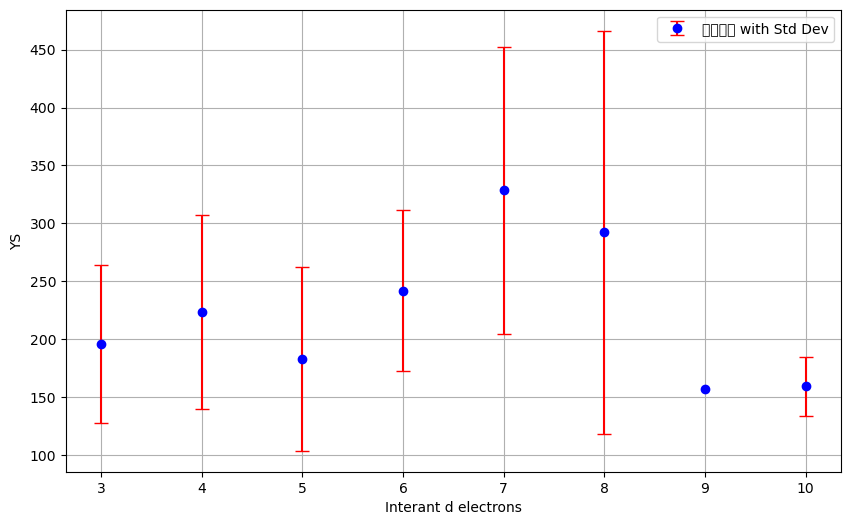

D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25239 (\N{CJK UNIFIED IDEOGRAPH-6297}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25289 (\N{CJK UNIFIED IDEOGRAPH-62C9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\envs\torch24\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


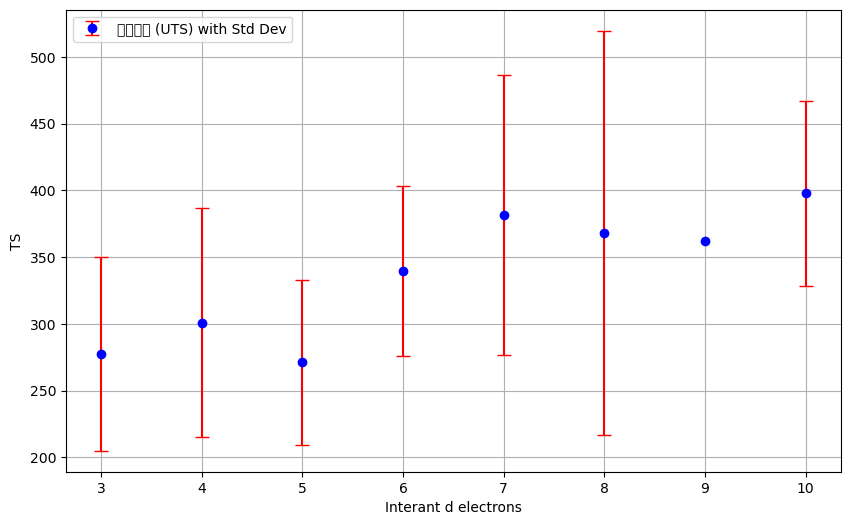

In [15]:
# 重新加载所需库
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df = pd.read_excel("FULL_general.xlsx", index_col=0)

# 过滤 "Interant d electrons" 在 3 到 10 之间的数据
filtered_df = df[(df["Interant d electrons"] >= 3) & (df["Interant d electrons"] <= 10)]

# 定义要分析的目标变量
targets = {
    "屈服强度": "Yield Strength vs Interant d electrons (Mean ± Std Dev)",
    "抗拉强度 (UTS)": "Tensile Strength vs Interant d electrons (Mean ± Std Dev)"
}

# 创建一个字典用于存储数据
output_data = {}

# 遍历目标变量，分别计算均值和标准差，并绘制误差条形图
for target, title in targets.items():
    grouped_df = filtered_df.groupby("Interant d electrons")[target]
    mean_values = grouped_df.mean()
    std_values = grouped_df.std()

    # 存储数据
    output_data[target] = pd.DataFrame({
        "Interant d electrons": mean_values.index,
        "Mean Value": mean_values.values,
        "Std Dev": std_values.values
    })

    # 绘制误差条形图
    plt.figure(figsize=(10, 6))
    plt.errorbar(mean_values.index, mean_values.values, yerr=std_values.values, fmt='o', 
                 color='blue', ecolor='red', capsize=5, label=f"{target} with Std Dev")

    plt.xlabel("Interant d electrons")
    if "屈服" in target:
        target = "YS"
    else:
        target = "TS"
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.show()

# 保存数据到 Excel
output_file = "Interant_d_electrons_analysis.xlsx"
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    for key, df_out in output_data.items():
        df_out.to_excel(writer, sheet_name=key, index=False)


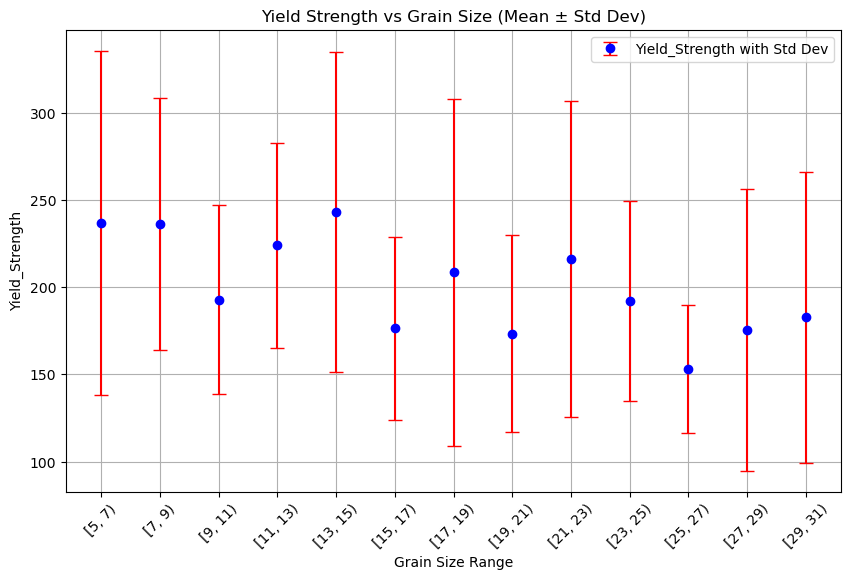

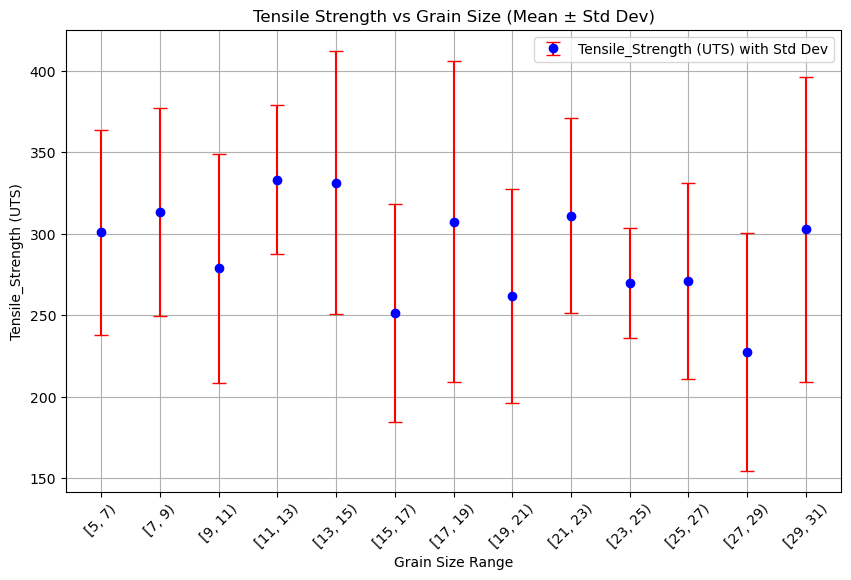

Results saved to Grain_Size_vs_Strength.xlsx


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取 Excel 文件
df = pd.read_excel("FULL_general.xlsx", index_col=0)
df.rename(columns={"屈服强度": "Yield_Strength", "抗拉强度 (UTS)": "Tensile_Strength (UTS)"}, inplace=True)

# 定义 Grain Size 分组区间（例如，5 到 30，步长为 2）
bin_edges = np.arange(5, 32, 2)  # 生成区间：5-7, 7-9, ..., 29-31
df["Grain Size Bin"] = pd.cut(df["Grain Size"], bins=bin_edges, right=False)

# 定义要分析的目标变量
targets = {
    "Yield_Strength": "Yield Strength vs Grain Size (Mean ± Std Dev)",
    "Tensile_Strength (UTS)": "Tensile Strength vs Grain Size (Mean ± Std Dev)"
}

# 创建一个字典用于存储数据
output_data = {}

# 遍历目标变量，计算均值和标准差，并绘制误差条形图
for target, title in targets.items():
    grouped_df = df.groupby("Grain Size Bin")[target]
    mean_values = grouped_df.mean()
    std_values = grouped_df.std()

    # 存储数据
    output_data[target] = pd.DataFrame({
        "Grain Size Bin": mean_values.index.astype(str),  # 将区间转换为字符串
        "Mean Value": mean_values.values,
        "Std Dev": std_values.values
    })

    # 绘制误差条形图
    plt.figure(figsize=(10, 6))
    plt.errorbar(mean_values.index.astype(str), mean_values.values, yerr=std_values.values, fmt='o', 
                 color='blue', ecolor='red', capsize=5, label=f"{target} with Std Dev")

    plt.xlabel("Grain Size Range")
    plt.ylabel(target)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

# 保存数据到 Excel
output_file = "Grain_Size_vs_Strength.xlsx"
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    for key, df_out in output_data.items():
        df_out.to_excel(writer, sheet_name=key, index=False)

print(f"Results saved to {output_file}")


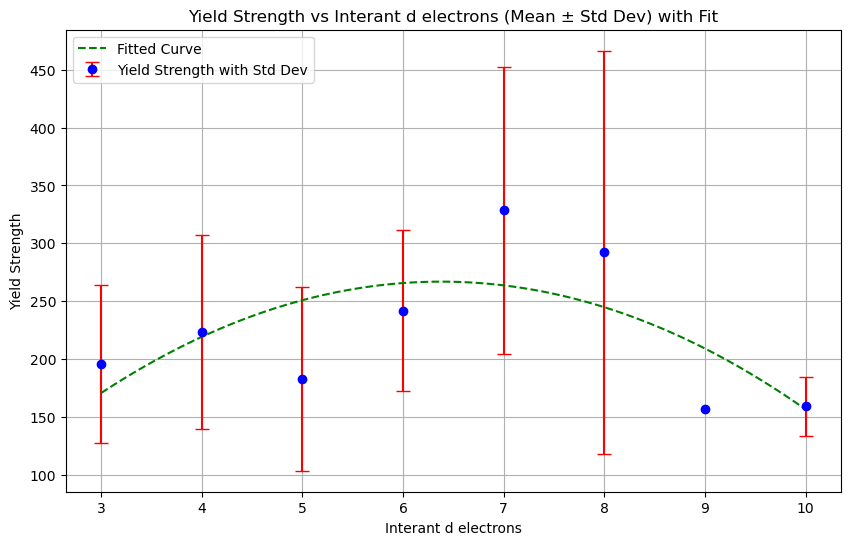

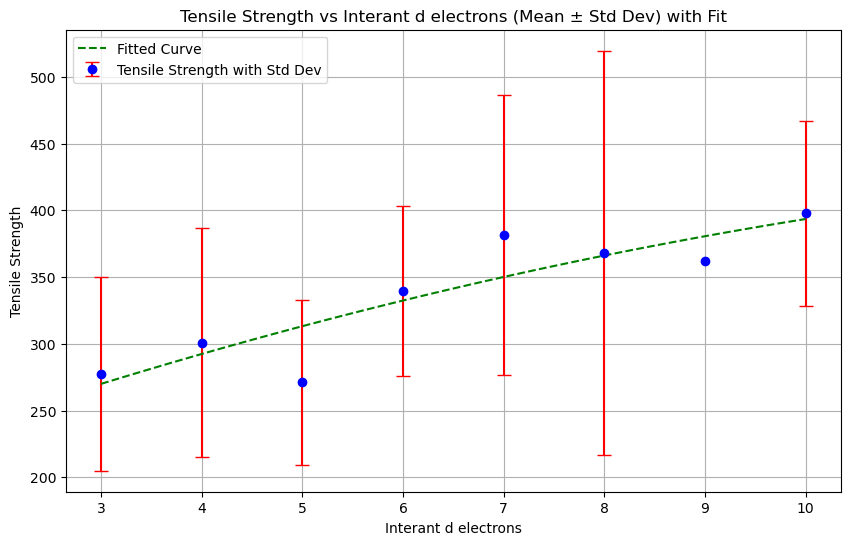

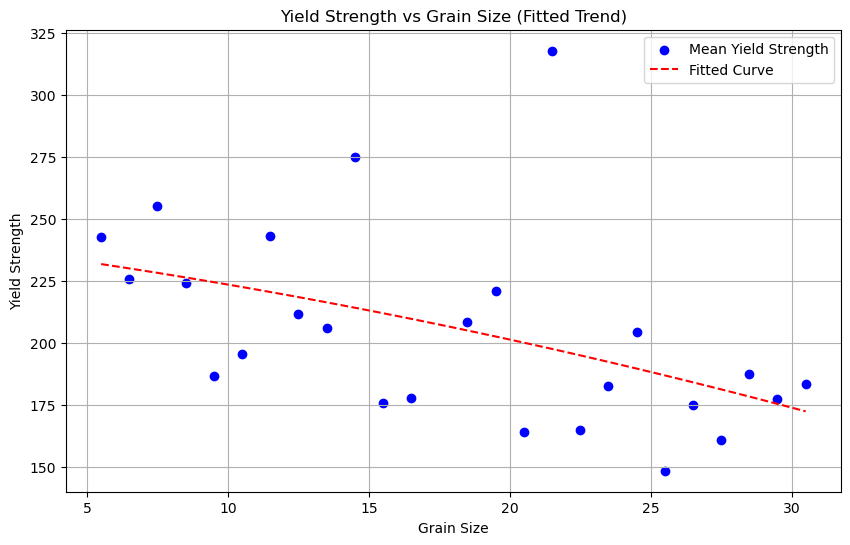

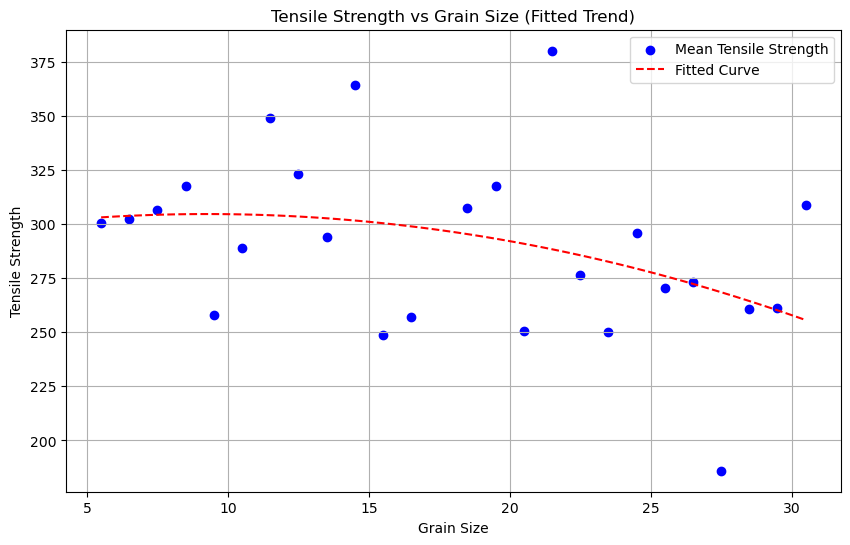

All sample data saved to Strength_Full_Samples.xlsx


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 读取 Excel 文件
df = pd.read_excel("FULL_general.xlsx", index_col=0)

# 修改列名（确保一致）
df.rename(columns={"屈服强度": "Yield_Strength", "抗拉强度 (UTS)": "Tensile_Strength (UTS)"}, inplace=True)

# 目标变量
targets = {
    "Yield_Strength": "Yield Strength",
    "Tensile_Strength (UTS)": "Tensile Strength"
}

# **保存所有样本数据**
output_file = "Strength_Full_Samples.xlsx"
df.to_excel(output_file, index=True)

# 定义拟合函数（二次拟合）
def quadratic_fit(x, a, b, c):
    return a * x**2 + b * x + c

# **1. 计算 Interant d electrons vs Strength**
for target, title in targets.items():
    # 筛选 Interant d electrons 在 3 到 10 之间的数据
    filtered_d = df[(df["Interant d electrons"] >= 3) & (df["Interant d electrons"] <= 10)]
    grouped_d = filtered_d.groupby("Interant d electrons")[target]
    mean_d = grouped_d.mean()
    std_d = grouped_d.std()

    # 二次拟合
    popt, _ = curve_fit(quadratic_fit, mean_d.index, mean_d.values)
    x_fit = np.linspace(mean_d.index.min(), mean_d.index.max(), 100)
    y_fit = quadratic_fit(x_fit, *popt)

    # **绘制误差条形图 + 拟合曲线**
    plt.figure(figsize=(10, 6))
    plt.errorbar(mean_d.index, mean_d.values, yerr=std_d.values, fmt='o', 
                 color='blue', ecolor='red', capsize=5, label=f"{title} with Std Dev")
    plt.plot(x_fit, y_fit, color='green', linestyle='--', label="Fitted Curve")

    plt.xlabel("Interant d electrons")
    plt.ylabel(title)
    plt.title(f"{title} vs Interant d electrons (Mean ± Std Dev) with Fit")
    plt.legend()
    plt.grid(True)
    plt.show()

# **2. 计算 Grain Size vs Strength（并进行拟合）**
bin_edges = np.arange(5, 32, 1)  # 以 1 为间隔
df["Grain Size Bin"] = pd.cut(df["Grain Size"], bins=bin_edges, right=False)

for target, title in targets.items():
    grouped_gs = df.groupby("Grain Size Bin")[target]
    mean_gs = grouped_gs.mean().dropna()  # **去除 NaN 以防止拟合错误**

    if not mean_gs.empty:  # **防止数据不足**
        # **计算区间中点**
        x_gs = np.array([bin.mid for bin in mean_gs.index])
        y_gs = mean_gs.values

        # **二次拟合**
        popt, _ = curve_fit(quadratic_fit, x_gs, y_gs)
        x_fit = np.linspace(x_gs.min(), x_gs.max(), 100)
        y_fit = quadratic_fit(x_fit, *popt)

        # **绘制拟合曲线**
        plt.figure(figsize=(10, 6))
        plt.scatter(x_gs, y_gs, color='blue', label=f"Mean {title}")
        plt.plot(x_fit, y_fit, color='red', linestyle='--', label="Fitted Curve")

        plt.xlabel("Grain Size")
        plt.ylabel(title)
        plt.title(f"{title} vs Grain Size (Fitted Trend)")
        plt.legend()
        plt.grid(True)
        plt.show()

# **保存完整数据**
df.to_excel("Strength_Full_Samples.xlsx", index=True)

print("All sample data saved to Strength_Full_Samples.xlsx")
